In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [32]:
def read_dataset(file, data_dir="data"):
    data_file_path = os.path.join(data_dir, file)
    data_matrix = np.loadtxt(data_file_path)
    input_data = data_matrix[:, :-1]
    output_data = data_matrix[:, -1].reshape((-1, 1))

    return input_data, output_data

In [33]:
X, y = read_dataset("PCB.dt")

# Task 1

In [34]:
def linear_regression(X, y):
    X_bias = np.hstack((X, np.ones((X.shape[0], 1))))
    X_dagger = np.linalg.pinv(X_bias)
    w_bias = X_dagger @ y
    w, b = w_bias[:-1], w_bias[-1]
    f = lambda x: (w.T @ x) + b # since we operate on the whole matrix, w.T @ x becomes X @ w
    return w, b, f

def mean_squared_error(y, y_hat):
    return np.mean((y - y_hat) ** 2)

In [35]:
w_linear, b_linear, f_linear = linear_regression(X, y)
x = X.reshape((1, -1))
print(x.shape, w_linear.shape)
y_hat = f_linear(x)
mse_linear = mean_squared_error(y, y_hat)

(1, 28) (1, 1)


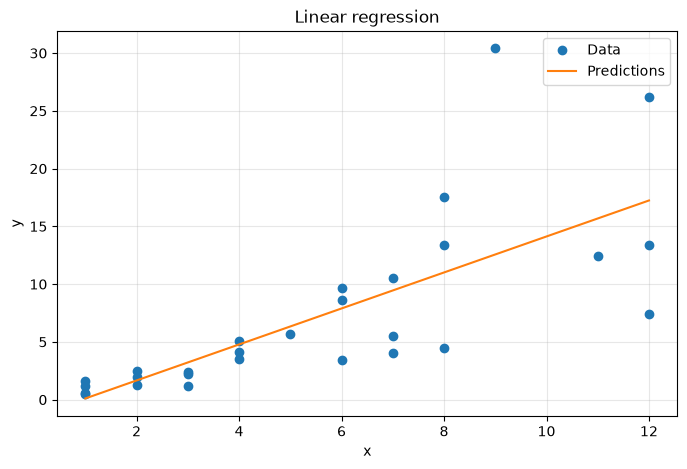

In [36]:
x_plot = x.flatten()
order = np.argsort(x_plot.flatten())
x_plot = x_plot[order]
y_plot = y.flatten()[order]
y_hat_plot = y_hat.flatten()[order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_plot, y_plot, "o", label="Data")
ax.plot(x_plot, y_hat_plot, "-", label="Predictions")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Linear regression")
ax.grid(alpha=0.3)
ax.legend()
plt.show()